Python 3.10.12


In [1]:
# Step 1: Import necessary modules

import sys
from pathlib import Path

# Add the project directory to sys.path
base_path = Path("/Users/rakhit/Desktop/YEAR 3/TradeLenseNepse")
sys.path.append(str(base_path))

# Import the module
from stock_analysis.stock_analyzer import analyze_stock
import json
from pathlib import Path
from stock_analysis.stock_analyzer import analyze_stock  # Import directly

# Step 2: Define the base path and config path
base_path = Path("/Users/rakhit/Desktop/YEAR 3/TradeLenseNepse")
config_path = base_path / "stock_analysis/config.json"

# Step 3: Load the config file
try:
    with open(config_path, "r") as f:
        config = json.load(f)
    print(f"Loaded config file from: {config_path}")
except FileNotFoundError:
    print(f"Error: Config file not found at {config_path}")
    raise
except json.JSONDecodeError as e:
    print(f"Error: Failed to parse config file: {e}")
    raise

# Step 4: Get the CSV file path for the current notebook
try:
    csv_path = config["csv_files"]["NEPSE"]
    print(f"CSV file path: {csv_path}")
except KeyError:
    print("Error: 'API' key not found in config['csv_files']")
    raise

# Step 5: Call the analyze_stock function
try:
    analyze_stock(csv_path)
    print("Function executed successfully.")
except Exception as e:
    print(f"Error in analyze_stock: {e}")

Loaded config file from: /Users/rakhit/Desktop/YEAR 3/TradeLenseNepse/stock_analysis/config.json
Error: 'API' key not found in config['csv_files']


KeyError: 'NEPSE'

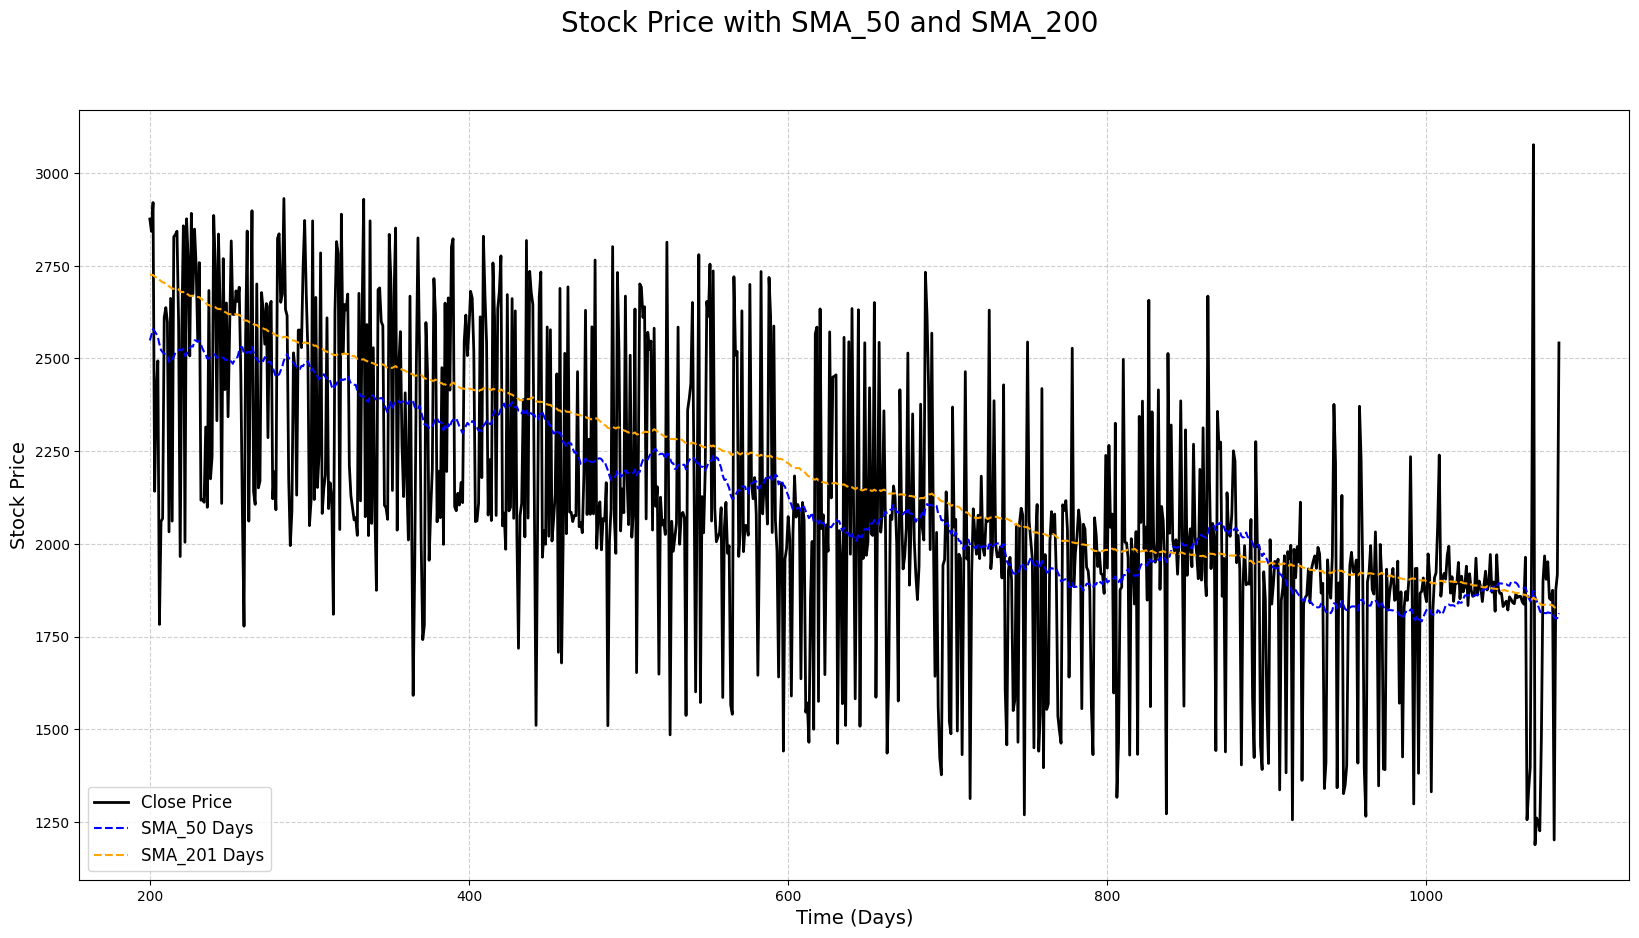

In [12]:
# Define the number of years for SMA calculations
sma_50_years = 0.2  # 50 trading days ≈ 0.2 years
sma_200_years = 0.8  # 200 trading days ≈ 0.8 years

# Convert years to days (assuming 252 trading days in a year)
sma_50_days = int(sma_50_years * 252)
sma_200_days = int(sma_200_years * 252)

# Calculate 50-day and 200-day Simple Moving Averages (SMA)
stock_data['SMA_50'] = stock_data['Close'].rolling(window=sma_50_days).mean()
stock_data['SMA_200'] = stock_data['Close'].rolling(window=sma_200_days).mean()

# Calculate volatility (30-day rolling standard deviation of returns)
volatility_days = int(30)  # 30 days for volatility calculation
stock_data['Volatility'] = stock_data['Close'].pct_change().rolling(window=volatility_days).std()

# Classify the trend
def classify_trend(row):
    if row['SMA_50'] > row['SMA_200']:
        return 'Bullish'
    elif row['SMA_50'] < row['SMA_200']:
        return 'Bearish'
    else:
        return 'Neutral'

stock_data['Trend'] = stock_data.apply(classify_trend, axis=1)

# Assess risk based on volatility
volatility_mean = stock_data['Volatility'].rolling(window=volatility_days).mean()

def assess_risk(row):
    if row['Volatility'] < volatility_mean.loc[row.name]:
        return 'Low'
    else:
        return 'High'

stock_data['Risk'] = stock_data.apply(assess_risk, axis=1)

# Drop rows with NaN values due to rolling calculations
stock_data = stock_data.dropna()

# Plot the stock price with SMA_50 and SMA_200
plt.figure(figsize=(20, 10))
plt.suptitle("Stock Price with SMA_50 and SMA_200", fontsize=20)
plt.plot(stock_data['Close'], label='Close Price', color='black', linewidth=2)
plt.plot(stock_data['SMA_50'], label=f'SMA_{sma_50_days} Days', color='blue', linestyle='--')
plt.plot(stock_data['SMA_200'], label=f'SMA_{sma_200_days} Days', color='orange', linestyle='--')
plt.xlabel("Time (Days)", fontsize=14)
plt.ylabel("Stock Price", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()